## Targets of this notebook
- find the anomalous behaviour within the dataset
- provide insights on data from ML perspecive (outlier-wise)
- serve as a first step towards anomaly detesction using Deep learning

In [40]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from src.plotting_styles import apply_global_style
from src.load_sam_data import load_dataset

# FJ

In [93]:
dataset = load_dataset("FJ")

here
datadir data\FJ\FI01X1\FI01X1_ch
data\FJ\FI01X1\FI01X1_ch


In [94]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
dataset = scaler.fit_transform(dataset)

neigh = NearestNeighbors(n_neighbors=len(dataset))
neigh.fit(dataset)

neighborhood = []
for d in dataset:
    dist, _ = neigh.kneighbors([d], return_distance=True)
    neighborhood.append(dist)

avg_distances = [np.mean(dist) for dist in neighborhood]

mean = np.mean(avg_distances)
deviations = [abs(d-mean) for d in avg_distances]

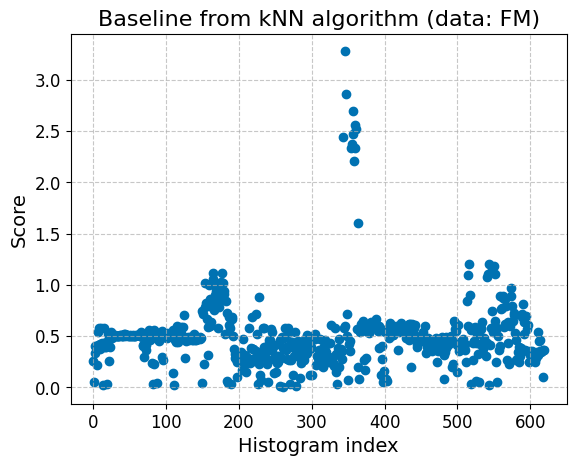

In [95]:
apply_global_style()
plt.title("Baseline from kNN algorithm (data: FM)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(deviations)), deviations)

# Is point 363 with score 1.6 an outlier?

In [96]:
possible_outlier =  [deviations.index(dev) for dev in deviations if dev < 2 and dev > 1.5]
possible_outlier

[363]

## Points that could be outliers

In [97]:
outliers_knn = [deviations.index(dev) for dev in deviations if dev > 1.5]
len(outliers_knn)

12

In [102]:
knn_weird = [deviations.index(dev) for dev in deviations if dev > 1]
knn_weird = [i for i in knn_weird if i > 500]
knn_weird

[514, 516, 541, 542, 543, 547, 550, 551]

In [104]:
deviations[555]

np.float64(0.5740635747798009)

In [27]:
table = {deviations.index(dev): round(dev, 4) for dev in deviations if dev > 1.5}
table

{343: np.float64(2.4439),
 346: np.float64(3.2819),
 347: np.float64(2.8582),
 354: np.float64(2.3356),
 355: np.float64(2.377),
 356: np.float64(2.4696),
 357: np.float64(2.6993),
 358: np.float64(2.2043),
 359: np.float64(2.5564),
 360: np.float64(2.331),
 361: np.float64(2.5217),
 363: np.float64(1.602)}

<BarContainer object of 96 artists>

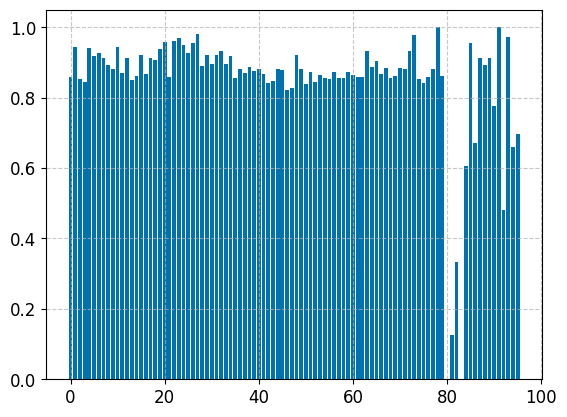

In [16]:
apply_global_style()
plt.bar(range(len(dataset[361])), dataset[361])

## Is point 113 outlier?

<BarContainer object of 96 artists>

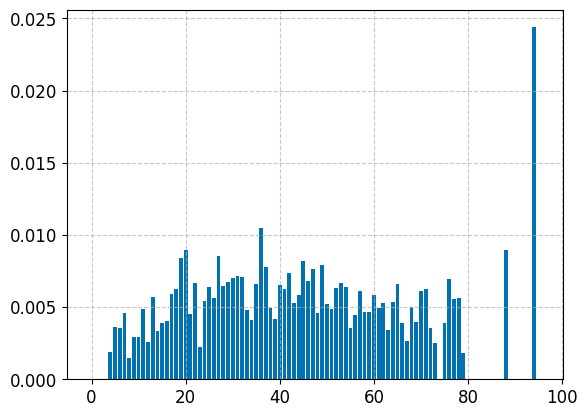

In [17]:
apply_global_style()

plt.bar(range(len(dataset[613])), dataset[113])

## Let's try OCSVM

In [12]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel='rbf').fit(dataset)
svm.fit_predict(dataset)
prediction = svm.predict(dataset)
out_measure = svm.score_samples(dataset)

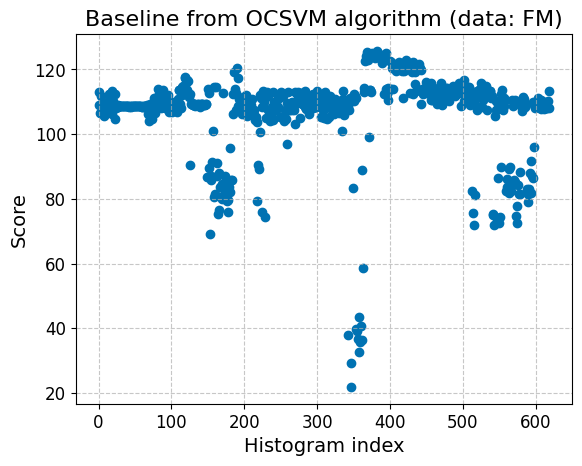

In [22]:
apply_global_style()
plt.title("Baseline from OCSVM algorithm (data: FM)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(out_measure)), out_measure)

In [24]:
outliers_svm = np.where(out_measure < 60)
outliers_svm = outliers_svm[0]

print("(SVM) Highest outlier score assigned to: ", np.where(out_measure == min(out_measure))[0].tolist())
print("(KNN) Highest outlier score assigned to: ", deviations.index(max(deviations)))
print(outliers_svm.tolist() == outliers_knn)
print(f"Outliers detected by svm {outliers_svm}")
print(f"Outliers detected by knn {outliers_knn}")

(SVM) Highest outlier score assigned to:  [346]
(KNN) Highest outlier score assigned to:  346
True
Outliers detected by svm [343 346 347 354 355 356 357 358 359 360 361 363]
Outliers detected by knn [343, 346, 347, 354, 355, 356, 357, 358, 359, 360, 361, 363]


True

In [84]:
from_ae =  [346, 357, 347, 359, 354, 356, 361, 355, 343, 360]
sum([1 for el in from_ae if el in outliers_svm])
len(from_ae)

10

In [35]:
table_svm = {idx : round(score, 4) for idx, score in enumerate(out_measure) if score < 60}
table_svm

{343: np.float64(37.9415),
 346: np.float64(21.8491),
 347: np.float64(29.2447),
 354: np.float64(39.6412),
 355: np.float64(39.256),
 356: np.float64(36.7774),
 357: np.float64(32.558),
 358: np.float64(43.5551),
 359: np.float64(35.6018),
 360: np.float64(40.5975),
 361: np.float64(36.3975),
 363: np.float64(58.6045)}

In [36]:
table_knn = {deviations.index(dev): round(dev, 4) for dev in deviations if dev > 1.5}
table_knn


{343: np.float64(2.4439),
 346: np.float64(3.2819),
 347: np.float64(2.8582),
 354: np.float64(2.3356),
 355: np.float64(2.377),
 356: np.float64(2.4696),
 357: np.float64(2.6993),
 358: np.float64(2.2043),
 359: np.float64(2.5564),
 360: np.float64(2.331),
 361: np.float64(2.5217),
 363: np.float64(1.602)}

# PA

In [57]:
pa_data = load_dataset("PA")

here
datadir data\MWPC\PA01U1\PA01U1_ch
data\MWPC\PA01U1\PA01U1_ch


<BarContainer object of 768 artists>

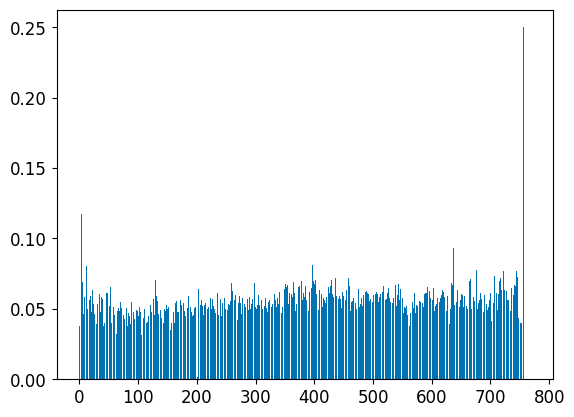

In [61]:
plt.bar(range(len(pa_data[0])), pa_data[0])

In [62]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
pa_data = scaler.fit_transform(pa_data)

neigh = NearestNeighbors(n_neighbors=len(pa_data))
neigh.fit(pa_data)

neighborhood = []
for d in pa_data:
    dist, _ = neigh.kneighbors([d], return_distance=True)
    neighborhood.append(dist)

avg_distances = [np.mean(dist) for dist in neighborhood]

mean = np.mean(avg_distances)
deviations = [abs(d-mean) for d in avg_distances]

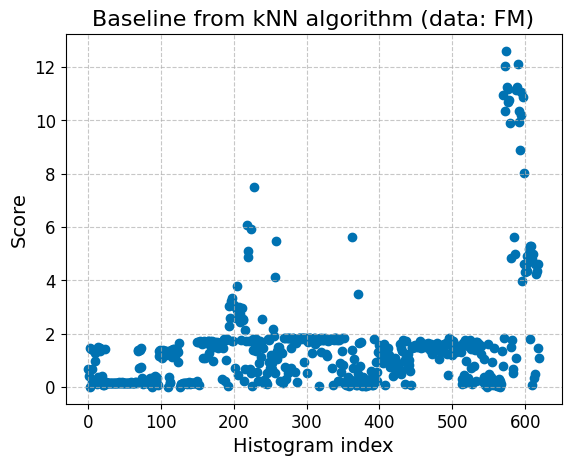

In [63]:
apply_global_style()
plt.title("Baseline from kNN algorithm (data: PA)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(deviations)), deviations)

In [68]:
outliers_knn = [deviations.index(dev) for dev in deviations if dev > 8]
len(outliers_knn), outliers_knn

(19,
 [570,
  572,
  573,
  574,
  575,
  576,
  577,
  578,
  579,
  588,
  589,
  590,
  591,
  592,
  593,
  594,
  595,
  597,
  598])

In [64]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel='rbf').fit(pa_data)
svm.fit_predict(pa_data)
prediction = svm.predict(pa_data)
out_measure = svm.score_samples(pa_data)

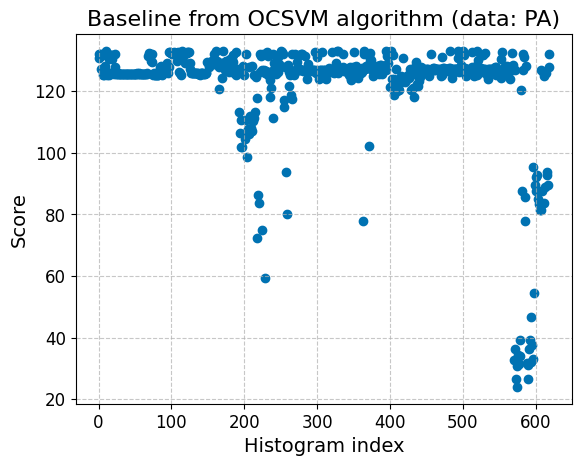

In [72]:
apply_global_style()
plt.title("Baseline from OCSVM algorithm (data: PA)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(out_measure)), out_measure)

In [69]:
outliers_svm = np.where(out_measure < 60)
outliers_svm = outliers_svm[0]

print("(SVM) Highest outlier score assigned to: ", np.where(out_measure == min(out_measure))[0].tolist())
print("(KNN) Highest outlier score assigned to: ", deviations.index(max(deviations)))
print(outliers_svm.tolist() == outliers_knn)
print(f"Outliers detected by svm {outliers_svm}")
print(f"Outliers detected by knn {outliers_knn}")

(SVM) Highest outlier score assigned to:  [574]
(KNN) Highest outlier score assigned to:  574
False
Outliers detected by svm [228 570 572 573 574 575 576 577 578 579 588 589 590 591 592 593 594 595
 597 598]
Outliers detected by knn [570, 572, 573, 574, 575, 576, 577, 578, 579, 588, 589, 590, 591, 592, 593, 594, 595, 597, 598]


Zde vidime ze pokud vezmeme hranici 60 ktera se zda byt vhodna dostavame v SVM pristupu o jeden outlier vice dataset je mnohem vice scattered a narozdil od predesleho FJ datasetu je v nem mnohem vic nejasnych bodu, ikdyz se na prvni pohled metody shodujji v skorovani vidime ze OCSVM je dulezite na zaklade tehto vysledku byt ostrazity hlavne v dobech ktere se nachazi mezi jasnymi outliery a clustrem bodu ktere jsou blizko u sebe.. (neco takoveho napsat idk)

# SI

In [70]:
si_data = load_dataset("SI")

here
datadir data\SI\SI01U1\SI01U1_ch
data\SI\SI01U1\SI01U1_ch


<BarContainer object of 1280 artists>

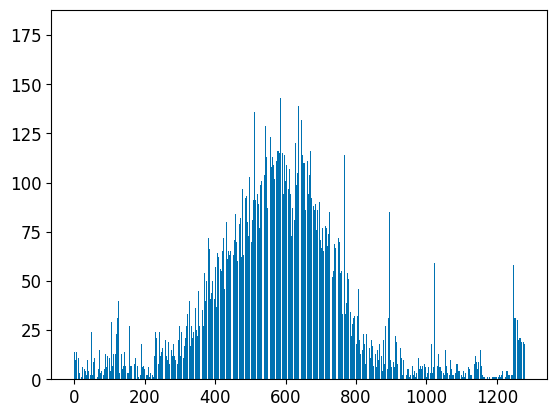

In [71]:
plt.bar(range(len(si_data[0])), si_data[0])

In [76]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
si_data = scaler.fit_transform(si_data)

neigh = NearestNeighbors(n_neighbors=len(si_data))
neigh.fit(si_data)

neighborhood = []
for d in si_data:
    dist, _ = neigh.kneighbors([d], return_distance=True)
    neighborhood.append(dist)

avg_distances = [np.mean(dist) for dist in neighborhood]

mean = np.mean(avg_distances)
deviations = [abs(d-mean) for d in avg_distances]

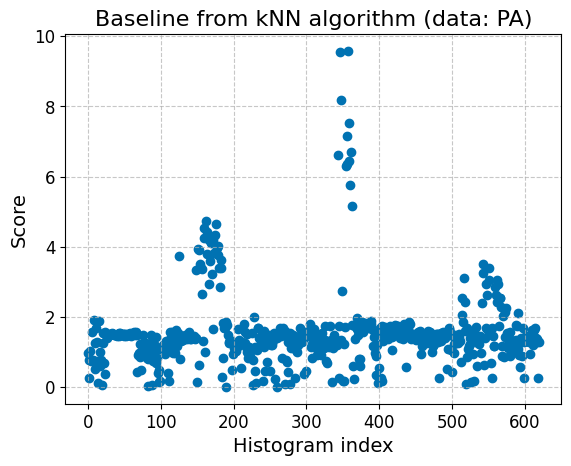

In [77]:
apply_global_style()
plt.title("Baseline from kNN algorithm (data: PA)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(deviations)), deviations)

In [74]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel='rbf').fit(si_data)
svm.fit_predict(si_data)
prediction = svm.predict(si_data)
out_measure = svm.score_samples(si_data)

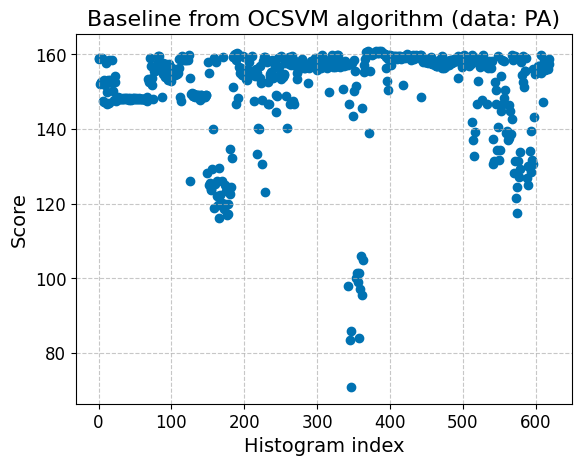

In [78]:
apply_global_style()
plt.title("Baseline from OCSVM algorithm (data: PA)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(out_measure)), out_measure)

In [80]:
outliers_svm = np.where(out_measure < 110)
outliers_svm = outliers_svm[0]

print("(SVM) Highest outlier score assigned to: ", np.where(out_measure == min(out_measure))[0].tolist())
print("(KNN) Highest outlier score assigned to: ", deviations.index(max(deviations)))
print(outliers_svm.tolist() == outliers_knn)
print(f"Outliers detected by svm {outliers_svm}")
print(f"Outliers detected by knn {outliers_knn}")

(SVM) Highest outlier score assigned to:  [346]
(KNN) Highest outlier score assigned to:  357
False
Outliers detected by svm [343 345 346 347 354 355 356 357 358 359 360 361 363]
Outliers detected by knn [570, 572, 573, 574, 575, 576, 577, 578, 579, 588, 589, 590, 591, 592, 593, 594, 595, 597, 598]
